# Artificial Intelligence in Medicine
## NOTEBOOK 1: Veri Temini, EDA ve Ön İşleme

Bu notebook çalıştırıldıktan sonra `processed_data.npz` dosyası üretilir.  
Model eğitimi için **Notebook 2**'yi kullanın.

---
**Çıktı:** `processed_data.npz` → Notebook 2 tarafından okunur  
**Veri:** Kaggle — Insulin Dosage Dataset

##  0 — Kurulum

In [10]:
!pip install kaggle seaborn plotly scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import warnings, os, pickle
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12, 'axes.labelsize': 11})

## 1 — Veri Temini

In [11]:
!pip install kagglehub -q

import kagglehub
import os
import pandas as pd

# Dataset indir
path = kagglehub.dataset_download("priyamchoksi/100000-diabetes-clinical-dataset")

print("Dataset path:", path)

# CSV dosyasını bul
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f'CSV dosyaları: {csv_files}')

# Veriyi yükle
df_raw = pd.read_csv(os.path.join(path, csv_files[0]))

print(f'Boyut : {df_raw.shape[0]:,} satır × {df_raw.shape[1]} sütun')
print(f'Sütunlar: {list(df_raw.columns)}')

df_raw.head()

Using Colab cache for faster access to the '100000-diabetes-clinical-dataset' dataset.
Dataset path: /kaggle/input/100000-diabetes-clinical-dataset
CSV dosyaları: ['diabetes_dataset.csv']
Boyut : 100,000 satır × 16 sütun
Sütunlar: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [12]:
# ── SEÇENEK B: Manuel yükleme ──
# Aşağıdaki satırların başındaki # işaretini kaldırın.
# from google.colab import files
# uploaded = files.upload()
# import io
# df_raw = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
# print('Manuel yükleme tamamlandı.')

In [13]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df_raw = pd.read_csv(os.path.join(path, csv_files[0]))

## 2 — EDA (Keşifsel Veri Analizi)

In [14]:
# ── 2.1 Genel Bakış ──
print('=== TEMEL İSTATİSTİKLER ===')
display(df_raw.describe(include='all').T)

=== TEMEL İSTATİSTİKLER ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,100000.0,NaN,NaN,NaN,2018.36082,1.345239,2015.0,2019.0,2019.0,2019.0,2022.0
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
location,100000,55,Kentucky,2038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race:AfricanAmerican,100000.0,NaN,NaN,NaN,0.20223,0.401665,0.0,0.0,0.0,0.0,1.0
race:Asian,100000.0,NaN,NaN,NaN,0.20015,0.400114,0.0,0.0,0.0,0.0,1.0
race:Caucasian,100000.0,NaN,NaN,NaN,0.19876,0.399069,0.0,0.0,0.0,0.0,1.0
race:Hispanic,100000.0,NaN,NaN,NaN,0.19888,0.39916,0.0,0.0,0.0,0.0,1.0
race:Other,100000.0,NaN,NaN,NaN,0.19998,0.399987,0.0,0.0,0.0,0.0,1.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0


In [15]:
# ── 2.2 Eksik Değer Analizi ──
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Eksik Sayı': missing, 'Eksik %': missing_pct})
miss_df = miss_df[miss_df['Eksik Sayı'] > 0].sort_values('Eksik %', ascending=False)

if len(miss_df) == 0:
    print('Eksik değer yok!')
else:
    print(f'{len(miss_df)} sütunda eksik değer var:')
    display(miss_df)

    fig, ax = plt.subplots(figsize=(10, max(3, len(miss_df)*0.5)))
    ax.barh(miss_df.index, miss_df['Eksik %'], color='#E74C3C', edgecolor='white')
    ax.set_xlabel('Eksik Değer Oranı (%)')
    ax.set_title('Sütun Başına Eksik Değer Oranı')
    for i, v in enumerate(miss_df['Eksik %']):
        ax.text(v + 0.2, i, f'{v}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('eda_01_missing_values.png', bbox_inches='tight')
    plt.show()

Eksik değer yok!


Olası hedef sütunlar: []
Seçilen hedef sütun: "diabetes"


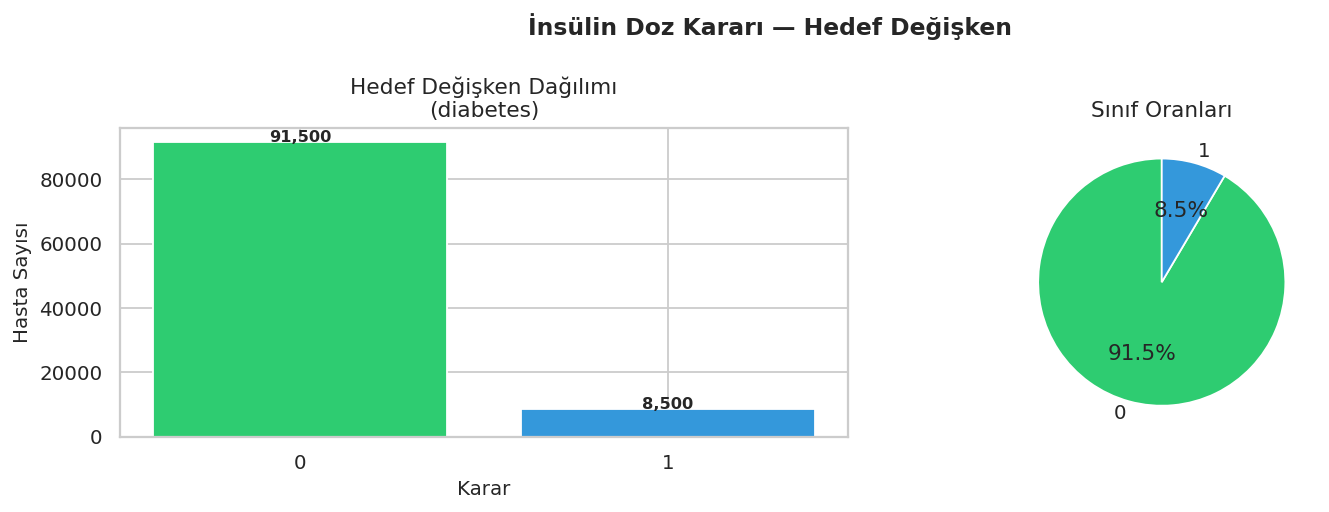

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [16]:
# ── 2.3 Hedef Değişkeni Tespit Et ve Görselleştir ──
possible_targets = [c for c in df_raw.columns
                    if any(k in c.lower() for k in ['dose','label','target','class','action','insulin'])]
print(f'Olası hedef sütunlar: {possible_targets}')

TARGET_COL = possible_targets[0] if possible_targets else df_raw.columns[-1]
print(f'Seçilen hedef sütun: "{TARGET_COL}"')

counts = df_raw[TARGET_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ECC71','#3498DB','#E74C3C','#F39C12']

axes[0].bar(counts.index.astype(str), counts.values, color=colors[:len(counts)], edgecolor='white')
axes[0].set_title(f'Hedef Değişken Dağılımı\n({TARGET_COL})')
axes[0].set_xlabel('Karar')
axes[0].set_ylabel('Hasta Sayısı')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

axes[1].pie(counts.values, labels=counts.index.astype(str),
            autopct='%1.1f%%', colors=colors[:len(counts)],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Sınıf Oranları')

plt.suptitle('İnsülin Doz Kararı — Hedef Değişken', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_target_distribution.png', bbox_inches='tight')
plt.show()
print(counts)

Sayısal sütunlar (13): ['year', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


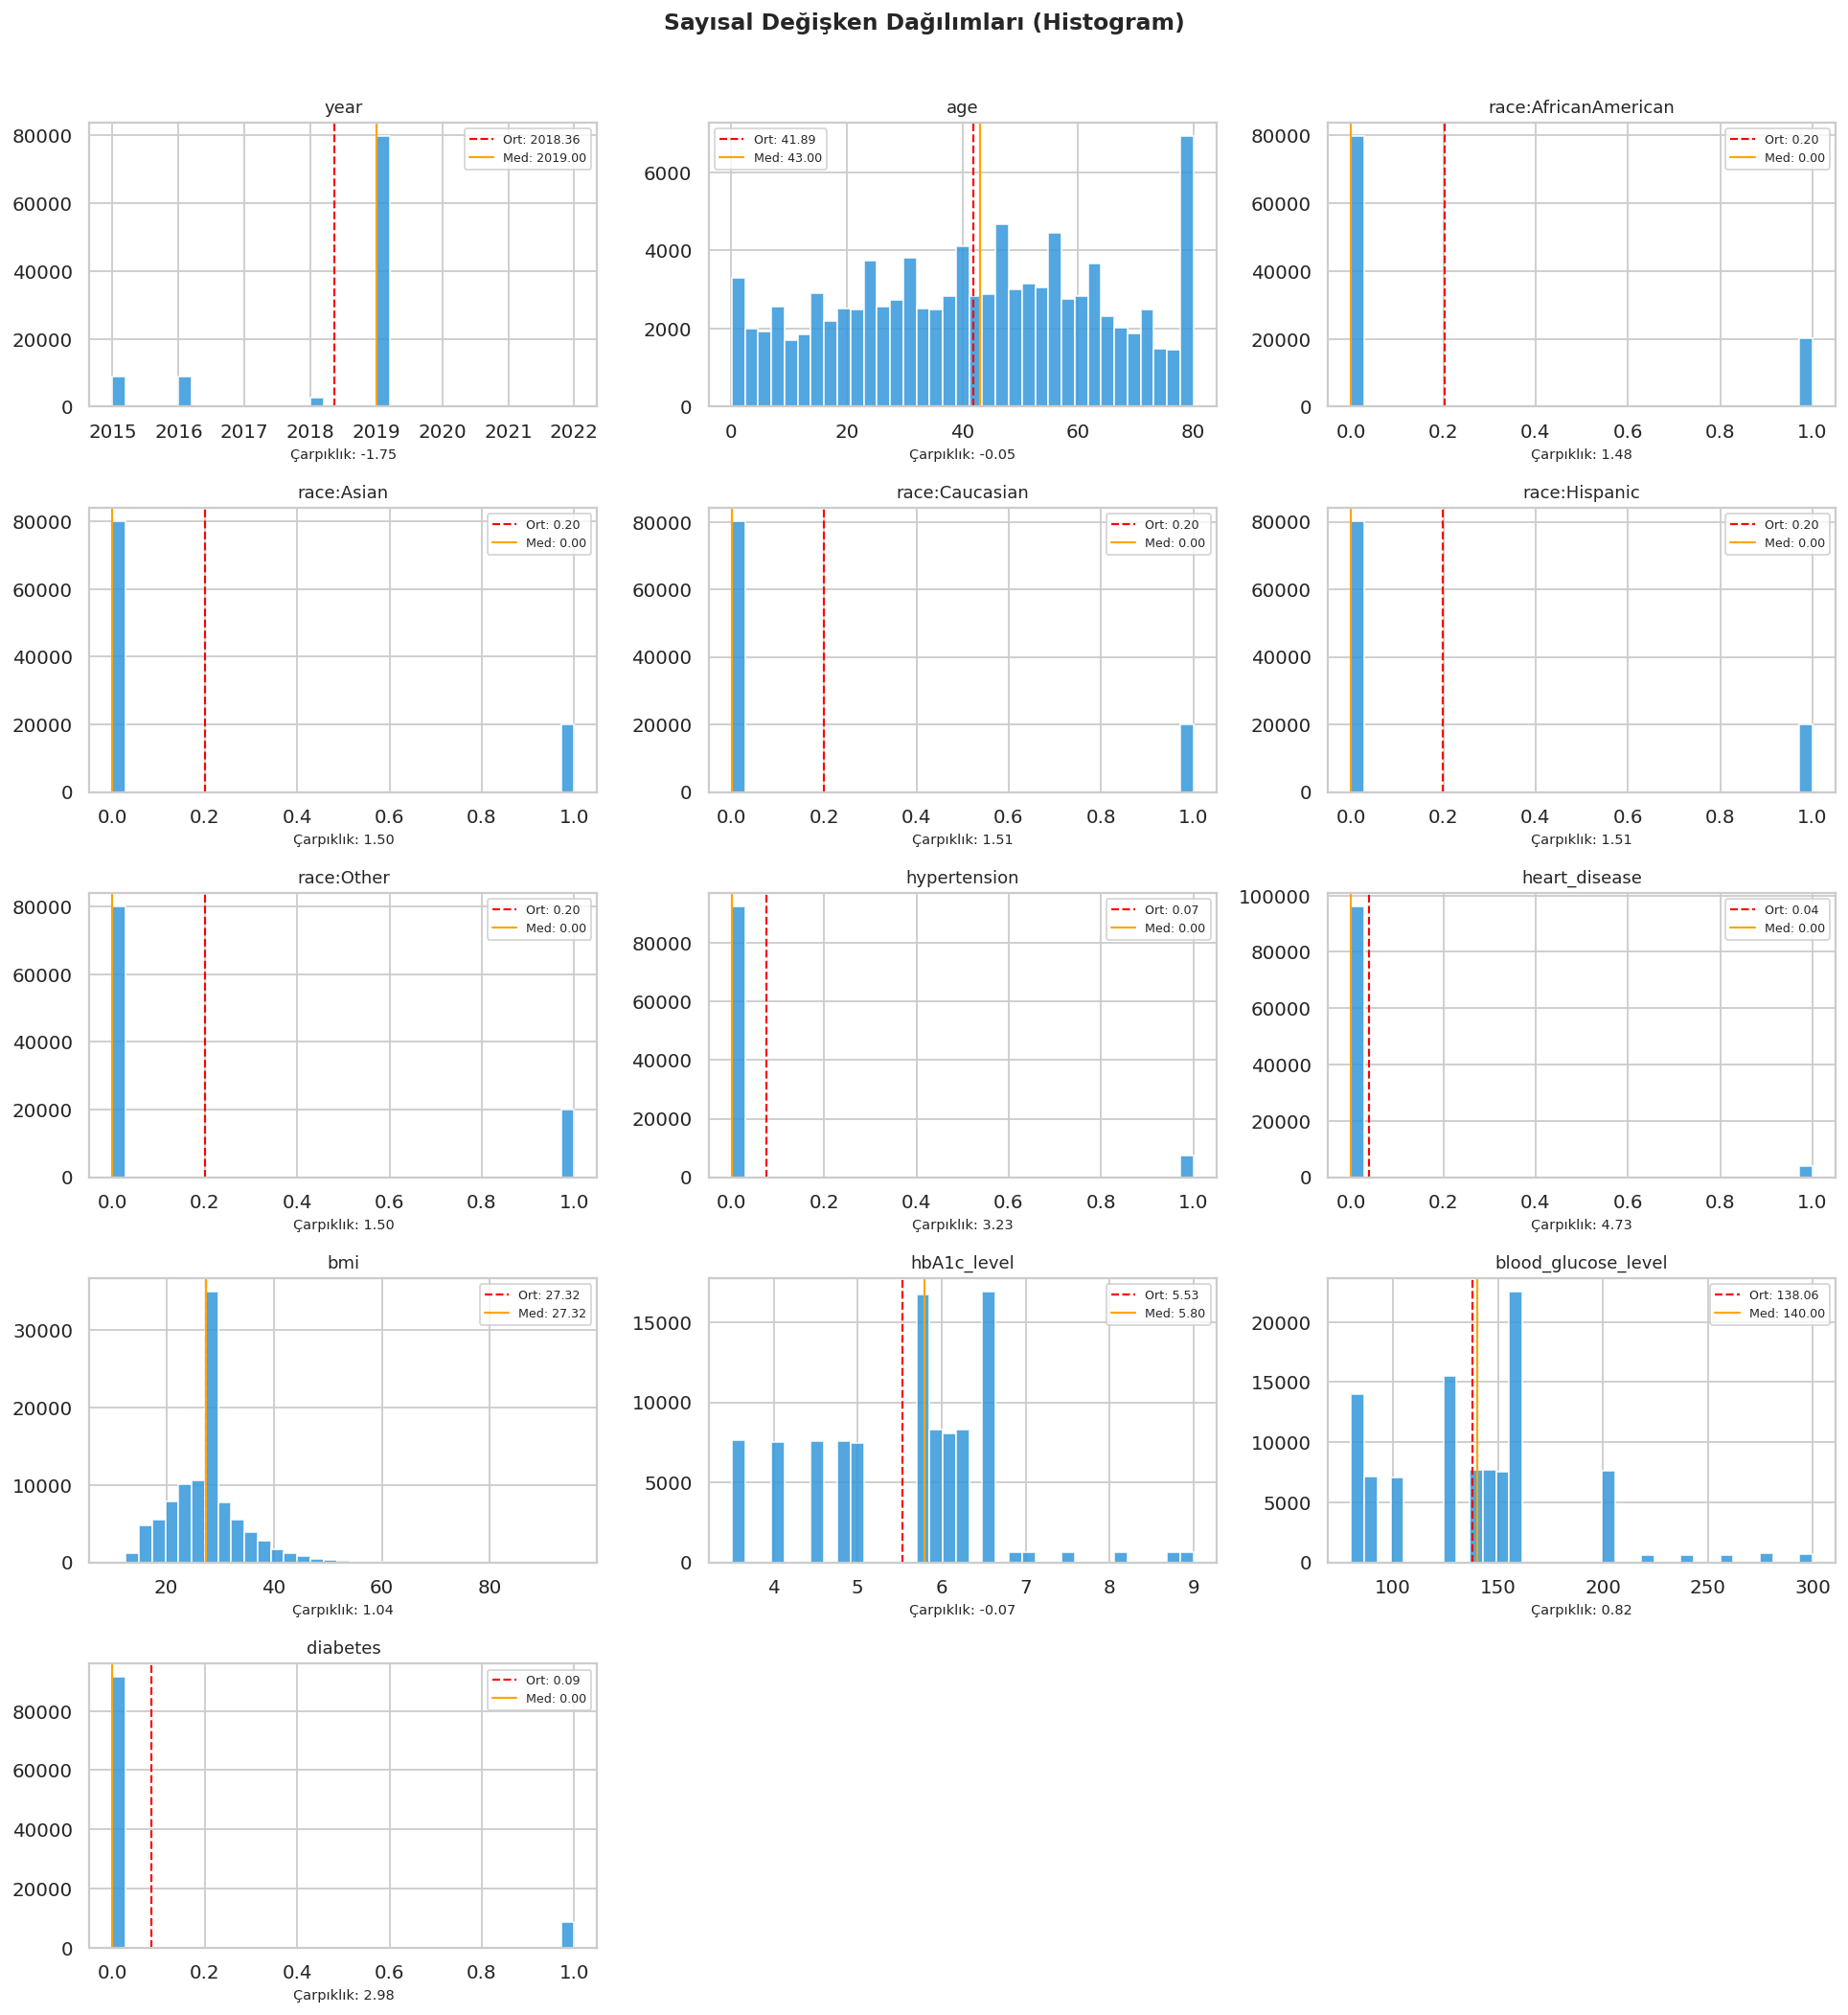

In [17]:
# ── 2.4 Sayısal Değişken Dağılımları ──
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f'Sayısal sütunlar ({len(num_cols)}): {num_cols}')

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.2))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols):
    data = df_raw[col].dropna()
    axes[i].hist(data, bins=35, color='#3498DB', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Ort: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='orange', linestyle='-',  linewidth=1.2, label=f'Med: {data.median():.2f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
    skew = data.skew()
    axes[i].set_xlabel(f'Çarpıklık: {skew:.2f}', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sayısal Değişken Dağılımları (Histogram)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_03_distributions.png', bbox_inches='tight')
plt.show()

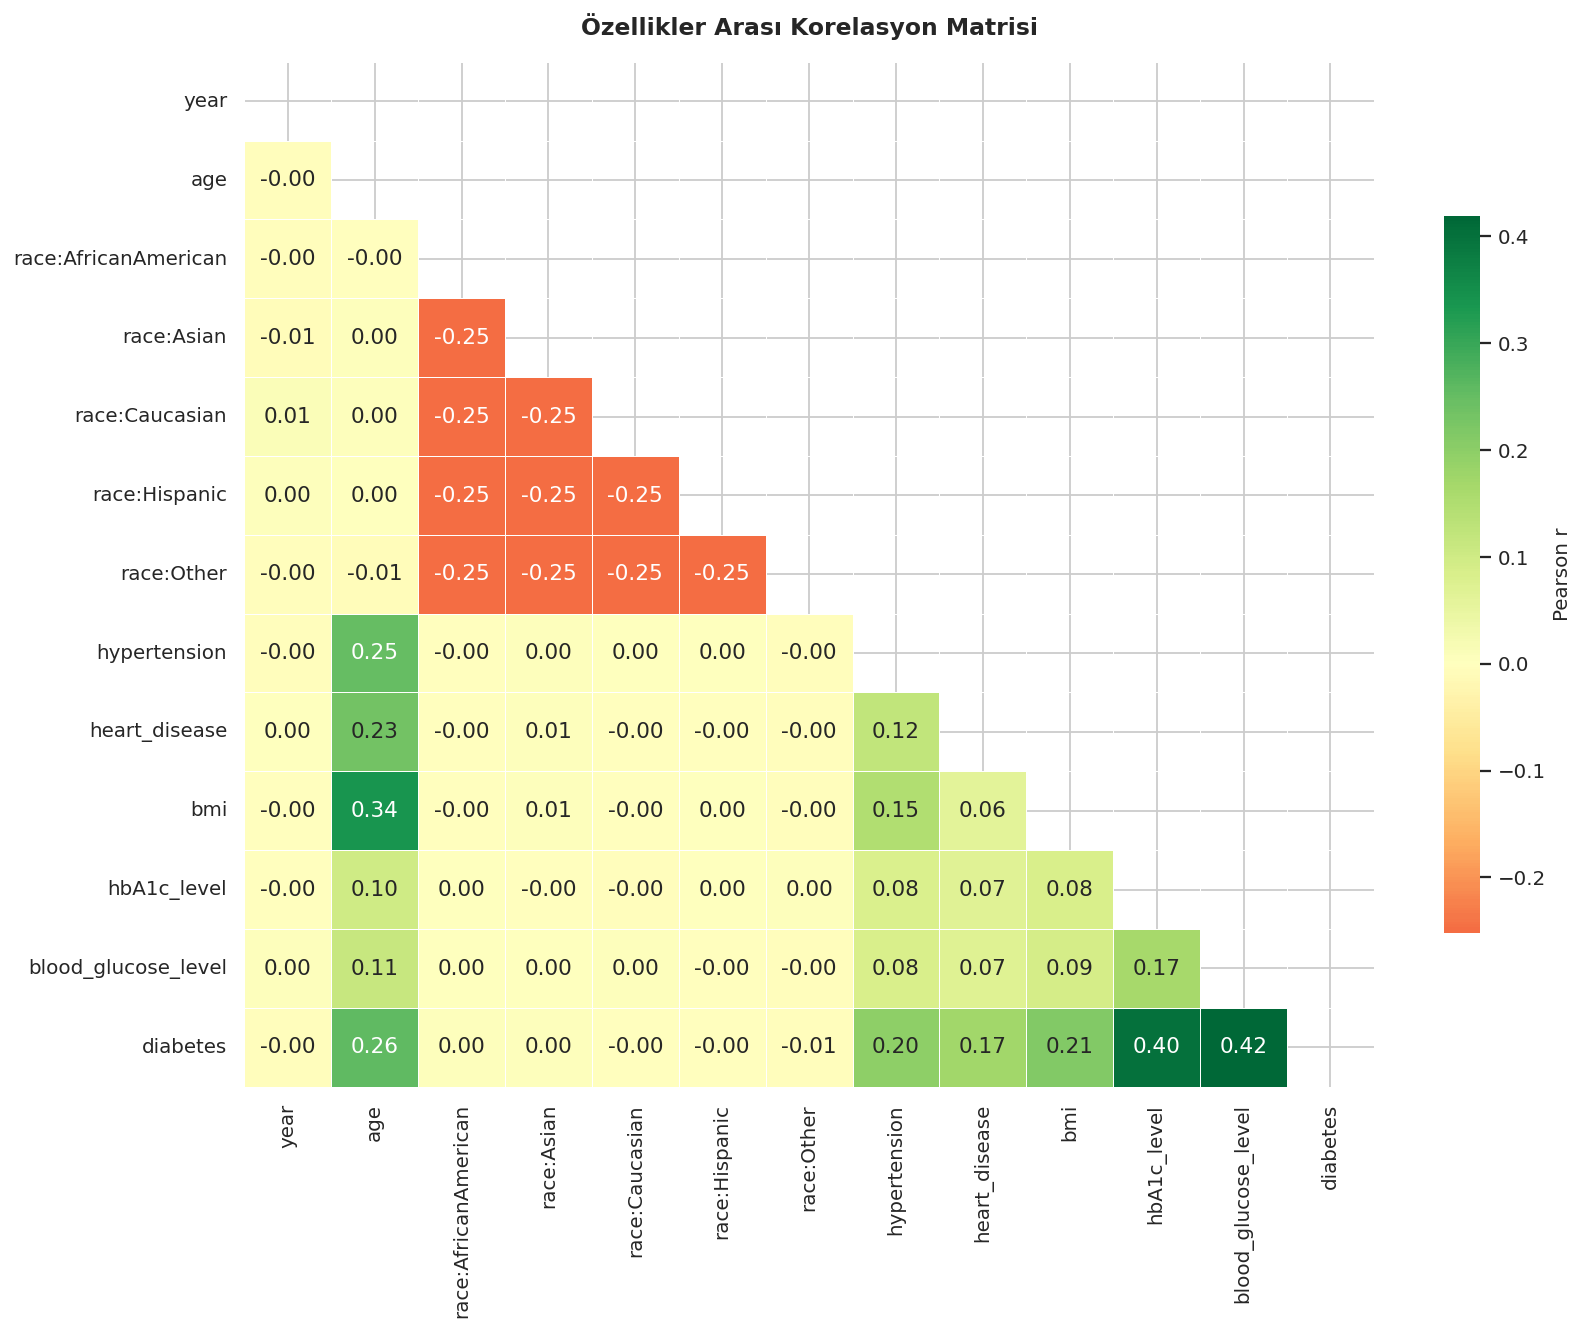


En Yüksek 10 Korelasyon:


,Değişken 1,Değişken 2,r
77,diabetes,blood_glucose_level,0.419558
76,diabetes,hbA1c_level,0.400660
37,bmi,age,0.337396
67,diabetes,age,0.258008
5,race:Asian,race:AfricanAmerican,-0.251859
17,race:Other,race:AfricanAmerican,-0.251725
22,hypertension,age,0.251171
12,race:Hispanic,race:AfricanAmerican,-0.250860
8,race:Caucasian,race:AfricanAmerican,-0.250765
18,race:Other,race:Asian,-0.250102


In [18]:
# ── 2.5 Korelasyon Matrisi ──
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(max(8, len(num_cols)), max(6, len(num_cols)*0.8)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
ax.set_title('Özellikler Arası Korelasyon Matrisi', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_04_correlation.png', bbox_inches='tight')
plt.show()

# En yüksek korelasyonlar
corr_pairs = (corr.where(mask == False)
               .stack()
               .reset_index()
               .rename(columns={'level_0':'Değişken 1','level_1':'Değişken 2', 0:'r'})
               .assign(abs_r=lambda d: d['r'].abs())
               .sort_values('abs_r', ascending=False)
               .head(10))
print('\nEn Yüksek 10 Korelasyon:')
display(corr_pairs[['Değişken 1','Değişken 2','r']])

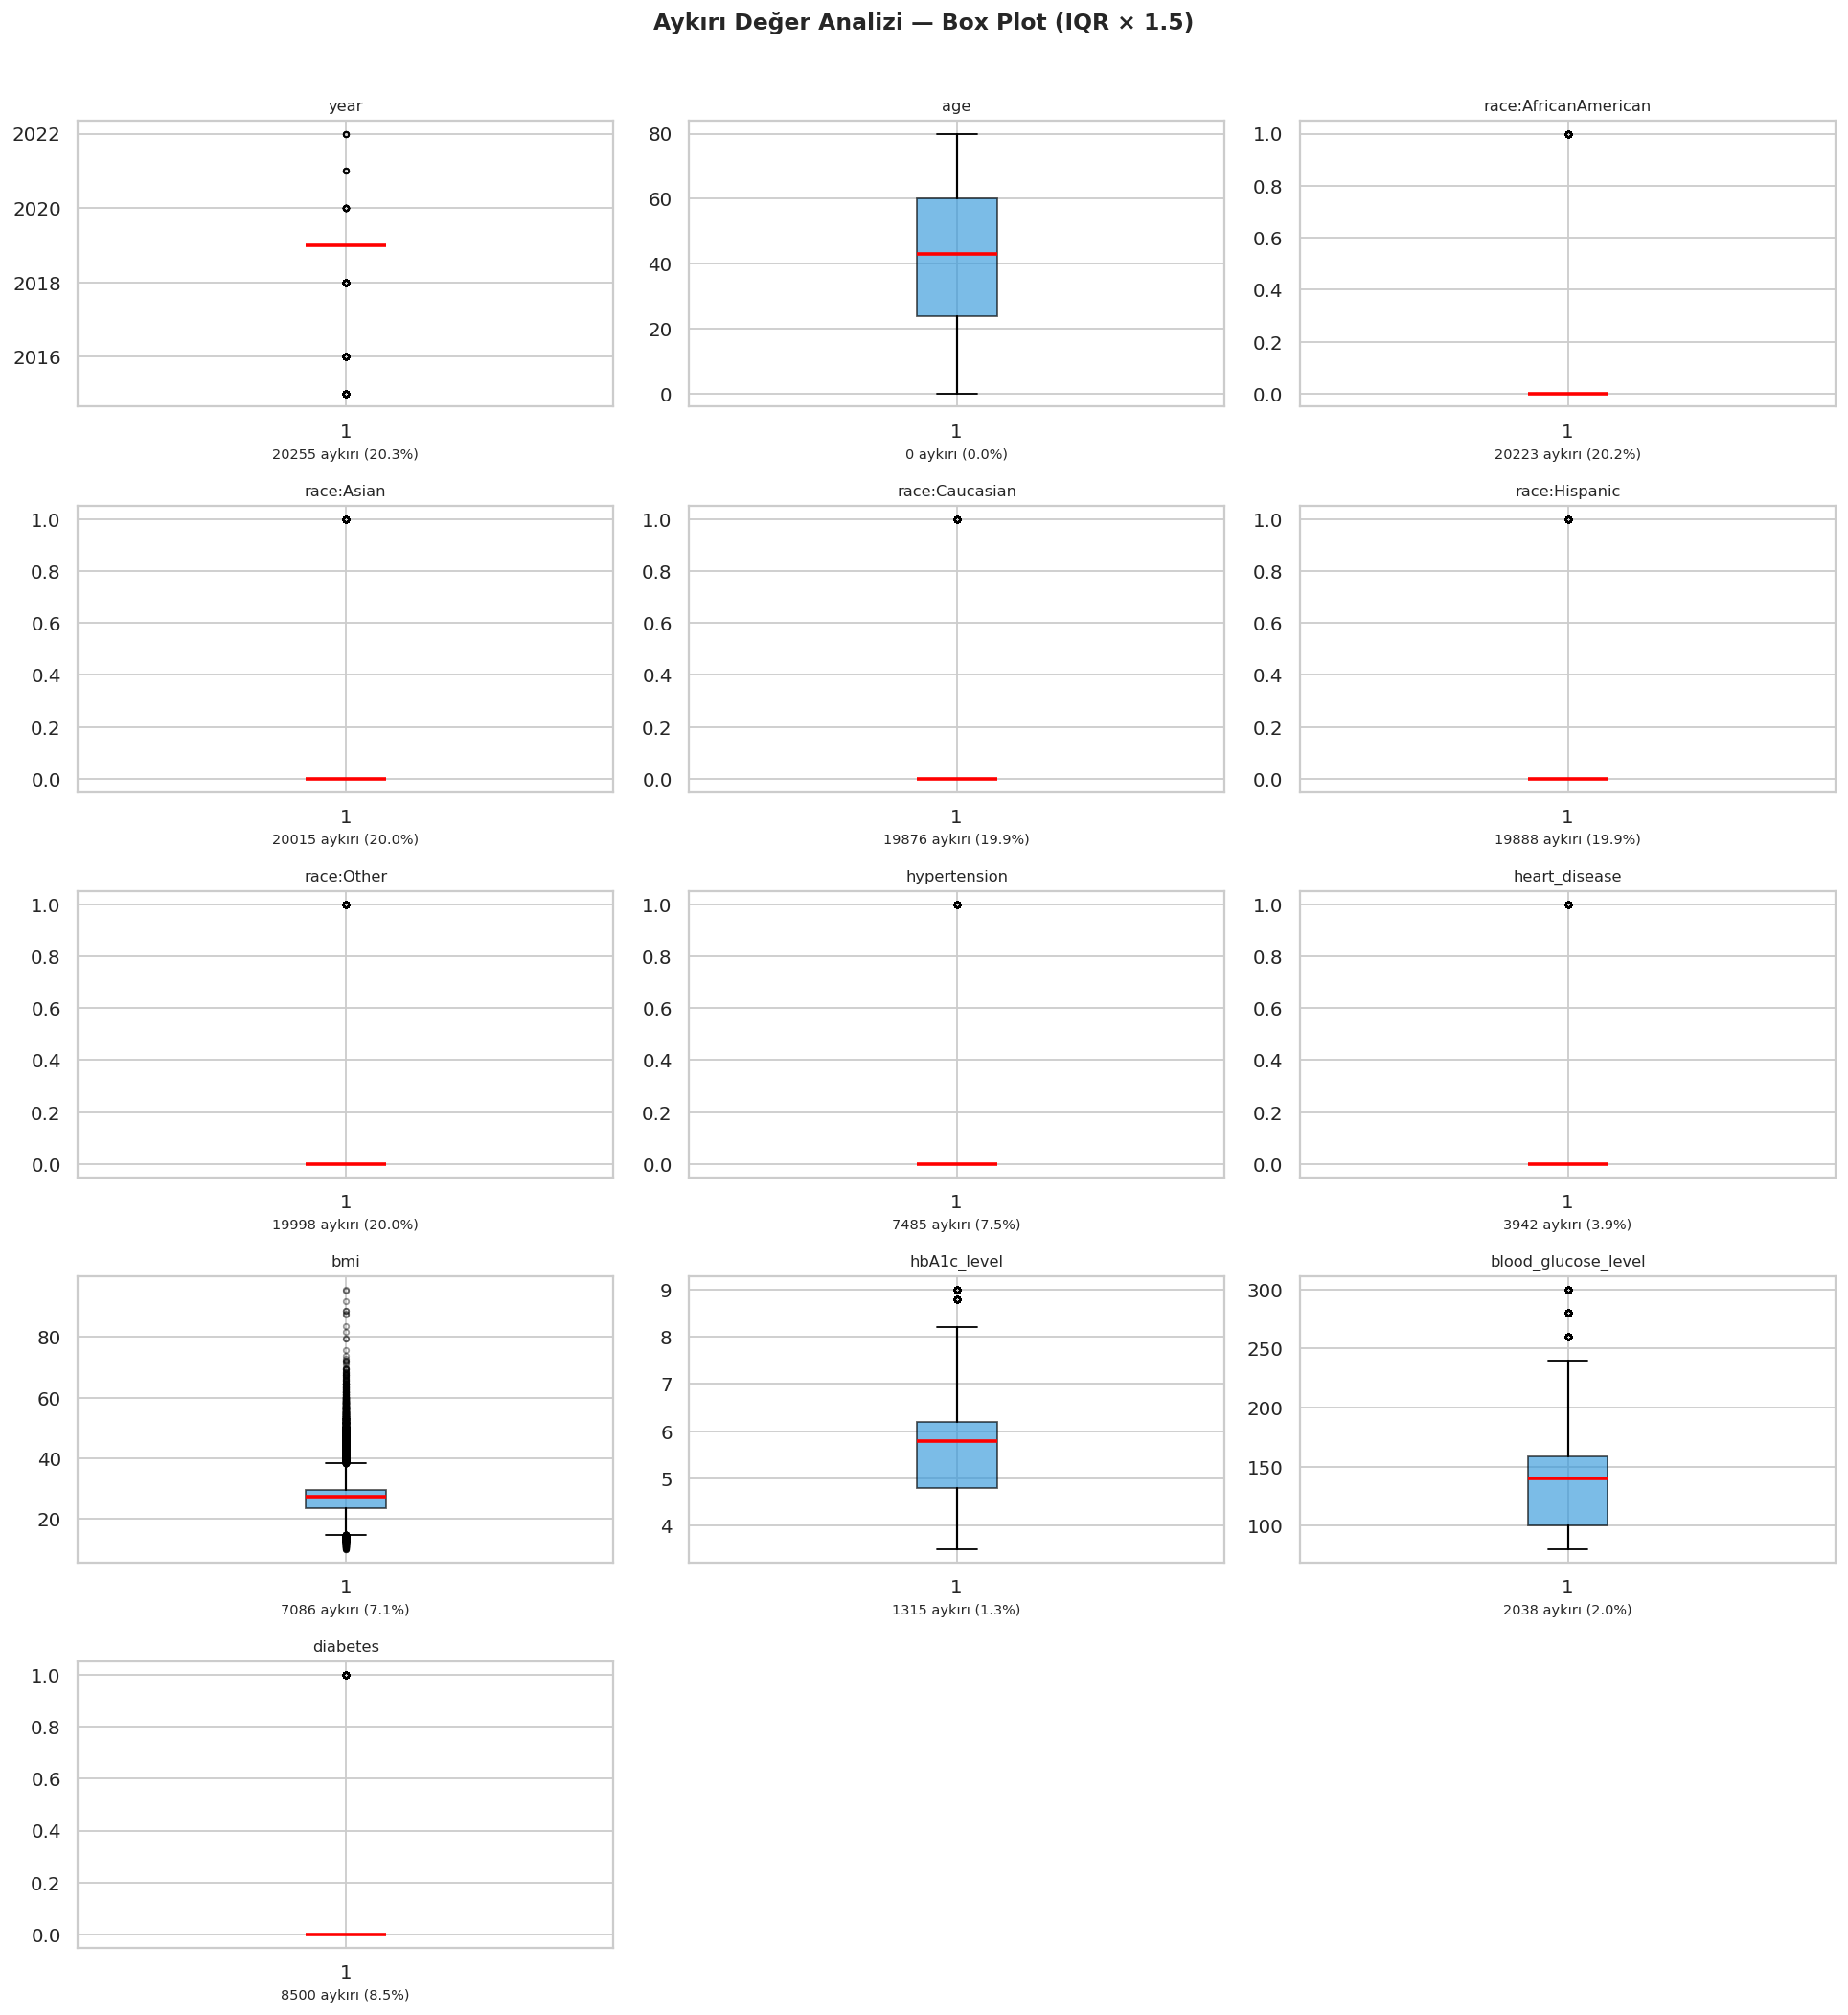


Aykırı Değer Özeti:


,Sütun,Aykırı Sayı,Oran (%)
0,year,20255,20.26
2,race:AfricanAmerican,20223,20.22
3,race:Asian,20015,20.02
6,race:Other,19998,20.00
5,race:Hispanic,19888,19.89
4,race:Caucasian,19876,19.88
12,diabetes,8500,8.50
7,hypertension,7485,7.48
9,bmi,7086,7.09
8,heart_disease,3942,3.94


In [19]:
# ── 2.6 Aykırı Değer Analizi (Box Plot + IQR) ──
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.2))
axes = np.array(axes).flatten()

outlier_summary = []
for i, col in enumerate(num_cols):
    data = df_raw[col].dropna()
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((data < lb) | (data > ub)).sum()
    pct_out = n_out / len(data) * 100
    outlier_summary.append({'Sütun': col, 'Aykırı Sayı': n_out, 'Oran (%)': round(pct_out,2)})

    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                         boxprops=dict(facecolor='#3498DB', alpha=0.65),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(linewidth=1.2),
                         flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#E74C3C'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel(f'{n_out} aykırı ({pct_out:.1f}%)', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Aykırı Değer Analizi — Box Plot (IQR × 1.5)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_05_outliers.png', bbox_inches='tight')
plt.show()

print('\nAykırı Değer Özeti:')
display(pd.DataFrame(outlier_summary).sort_values('Oran (%)', ascending=False))

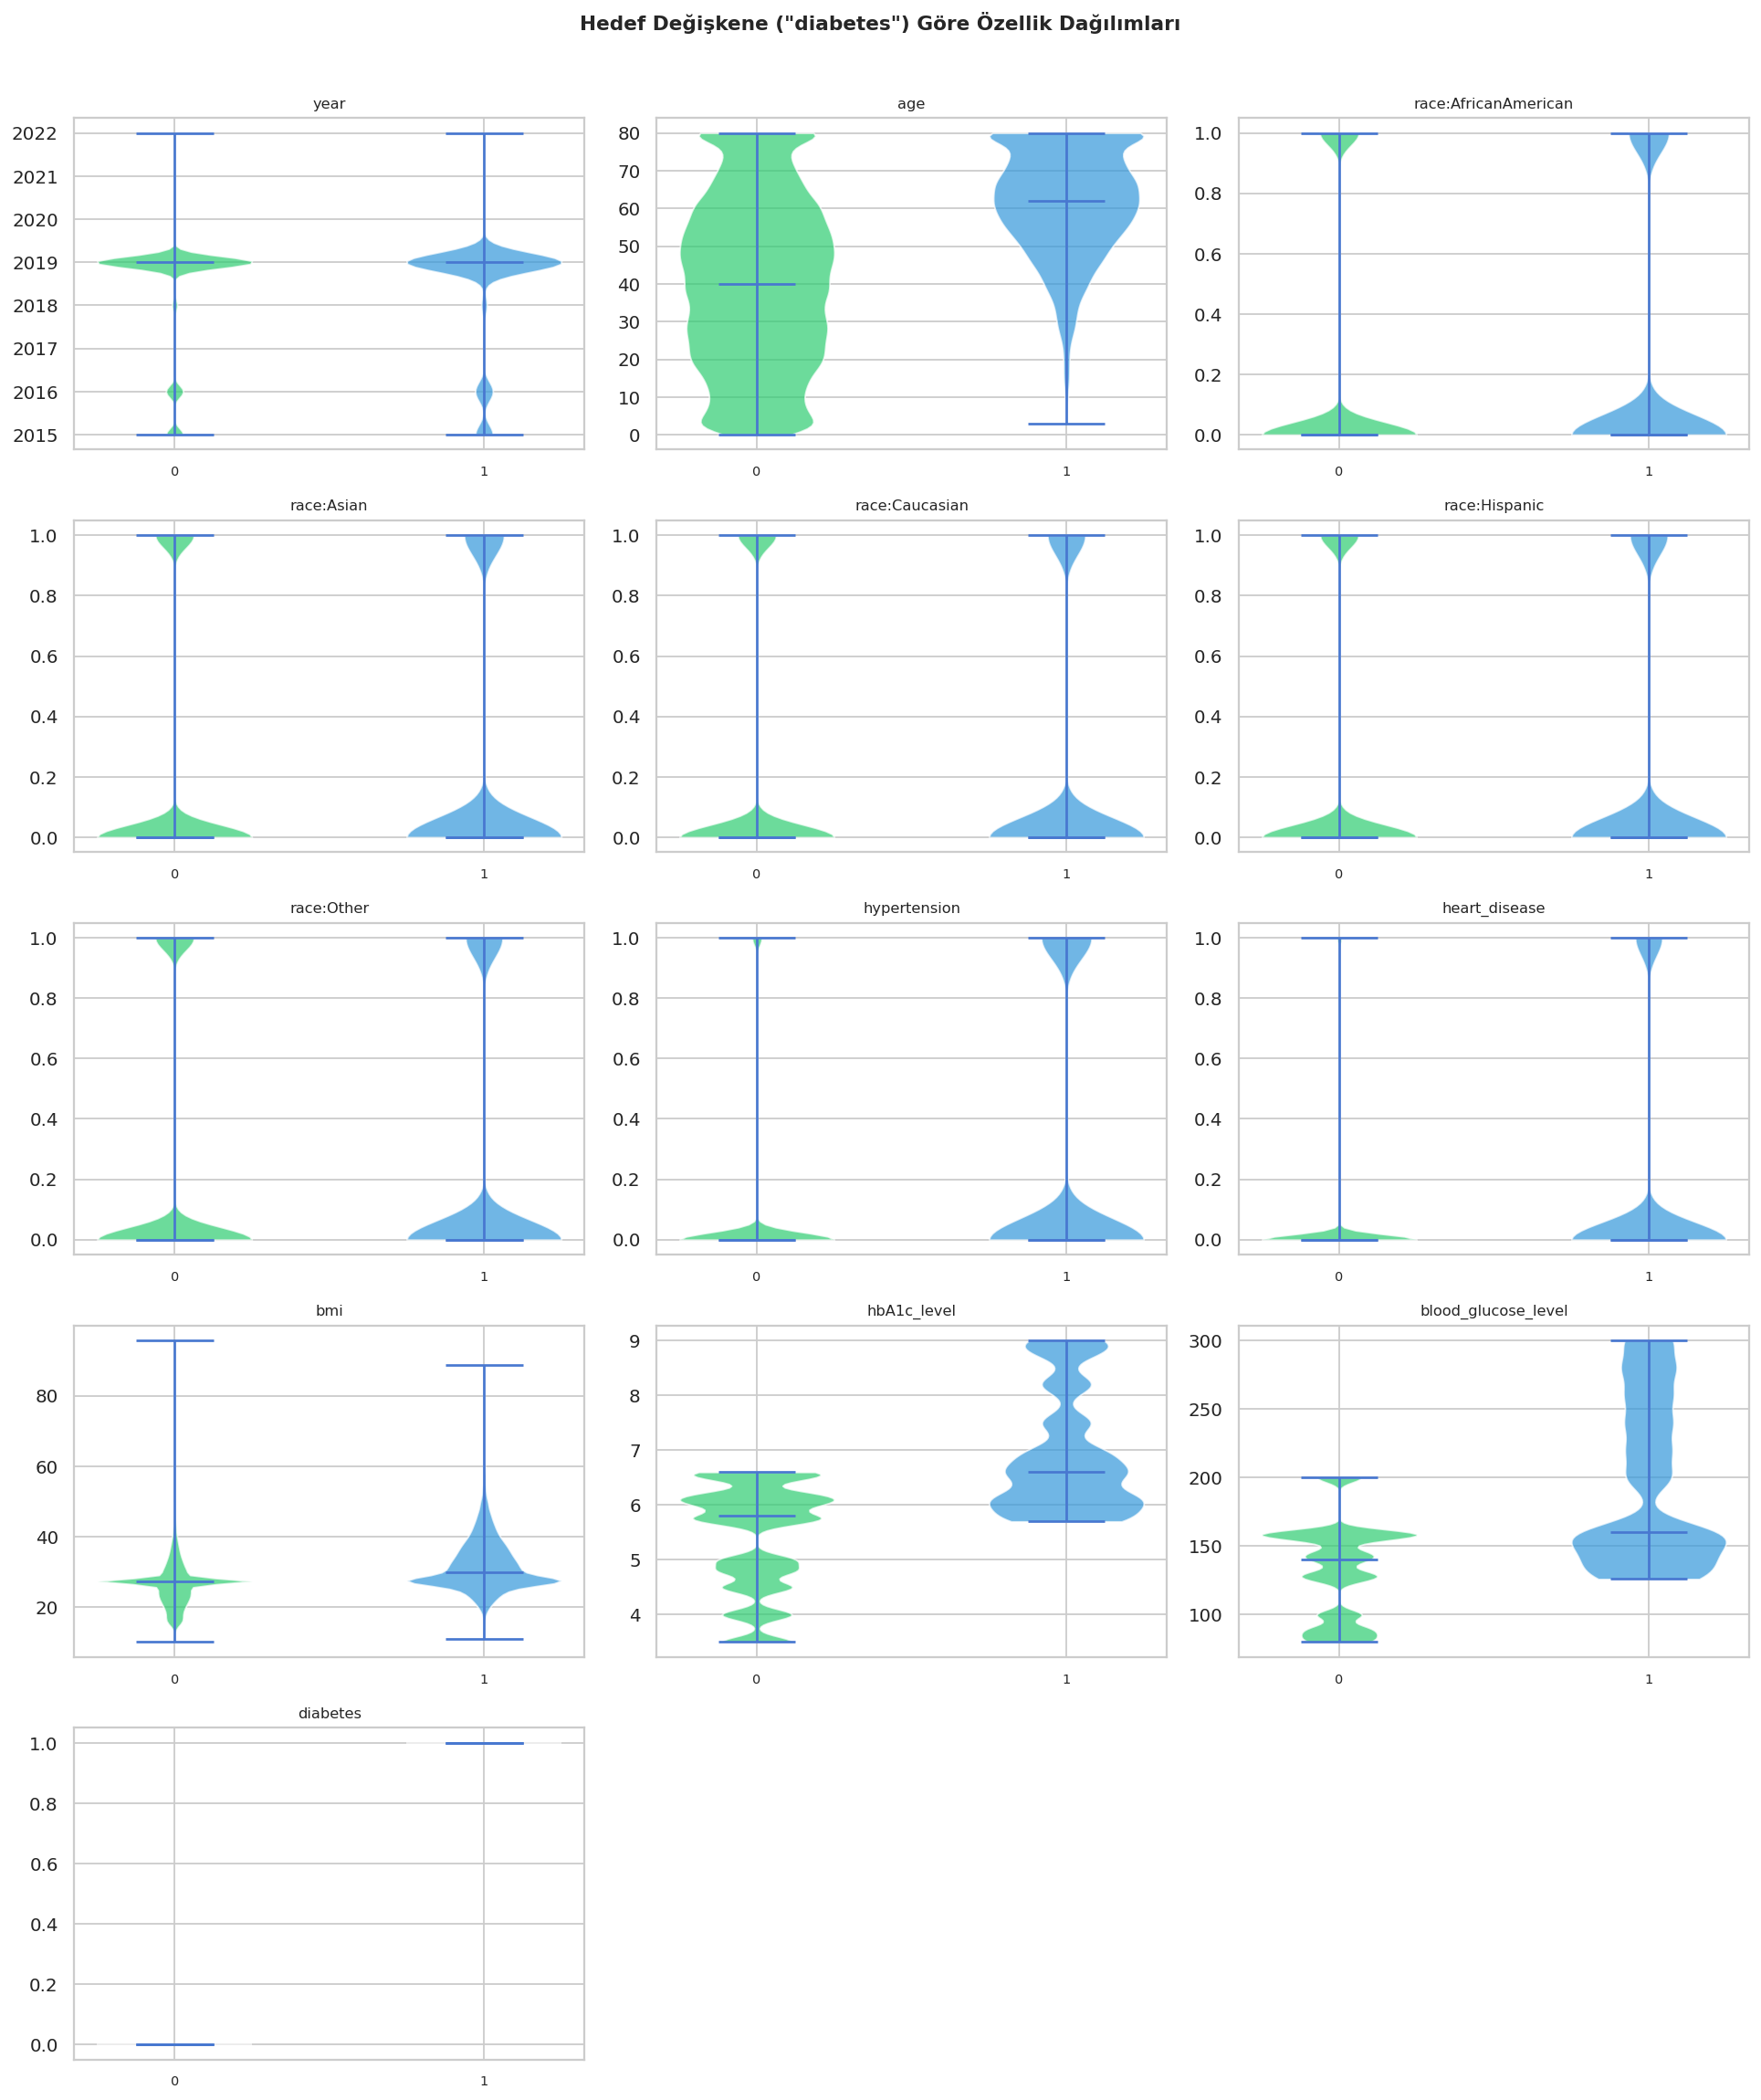

In [22]:
# ── 2.7 Hedef Değişkene Göre Özellik Dağılımı (Violin Plot) ──

# TARGET_COL garanti tek boyutlu olsun
target_series = df_raw[TARGET_COL]
if isinstance(target_series, pd.DataFrame):
    target_series = target_series.iloc[:, 0]

# Yeni df_viz oluştur
df_viz = df_raw[num_cols].copy()
df_viz[TARGET_COL] = target_series
df_viz = df_viz.dropna(subset=[TARGET_COL])

# Label'ları güvenli al
labels = sorted(df_viz[TARGET_COL].dropna().unique())

n = len(num_cols)
nrows_v = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows_v, ncols, figsize=(15, nrows_v * 3.5))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols):
    groups = [
        df_viz[df_viz[TARGET_COL] == label][col].dropna().values
        for label in labels
    ]

    vp = axes[i].violinplot(groups, showmedians=True)

    for j, body in enumerate(vp['bodies']):
        body.set_alpha(0.7)
        body.set_facecolor(['#2ECC71','#3498DB','#E74C3C','#F39C12'][j % 4])

    axes[i].set_xticks(range(1, len(labels)+1))
    axes[i].set_xticklabels([str(l) for l in labels], fontsize=8)
    axes[i].set_title(col, fontsize=9)

# Boş subplotları gizle
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Hedef Değişkene ("{TARGET_COL}") Göre Özellik Dağılımları',
             fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('eda_06_violin_by_target.png', bbox_inches='tight')
plt.show()

## 3 — Veri Temizleme ve Ön İşleme

In [23]:
# ── 3.1 Kopya ve eylem etiketleme ──
df = df_raw.copy()

NUM_ACTIONS  = 3
ACTION_NAMES = ['Azalt (dec)', 'Sabit Tut (keep)', 'Artır (inc)']

ACTION_MAP = {}
for label in df[TARGET_COL].unique():
    s = str(label).lower()
    if any(k in s for k in ['down','dec','azalt','reduce','lower']):
        ACTION_MAP[label] = 0
    elif any(k in s for k in ['up','inc','artir','artır','increase','raise']):
        ACTION_MAP[label] = 2
    else:
        ACTION_MAP[label] = 1

print(f'Eylem eşlemesi: {ACTION_MAP}')
df['action'] = df[TARGET_COL].map(ACTION_MAP)

# Eşleşemeyen satırları at
before = len(df)
df = df.dropna(subset=['action'])
df['action'] = df['action'].astype(int)
print(f'Temizleme öncesi: {before:,} | Sonrası: {len(df):,}')

Eylem eşlemesi: {np.int64(0): 1, np.int64(1): 1}
Temizleme öncesi: 100,000 | Sonrası: 100,000


In [24]:
# ── 3.2 Kategorik kodlama ──
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]
print(f'Kategorik sütunlar: {cat_cols}')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in [TARGET_COL, 'action']]
print(f'Özellik sütunları ({len(feature_cols)}): {feature_cols}')

Kategorik sütunlar: ['gender', 'location', 'smoking_history']
Özellik sütunları (15): ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level']


In [25]:
# ── 3.3 Eksik değer doldurma ──
imputer = SimpleImputer(strategy='median')
df[feature_cols] = imputer.fit_transform(df[feature_cols])
print(f'Eksik değer kalan: {df[feature_cols].isnull().sum().sum()}')

Eksik değer kalan: 0


In [26]:
# ── 3.4 Aykırı değer kırpma (IQR clip) ──
for col in feature_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    df[col] = df[col].clip(q1 - 1.5*iqr, q3 + 1.5*iqr)
print('Aykırı değerler kırpıldı.')

Aykırı değerler kırpıldı.


In [27]:
# ── 3.5 Normalizasyon (StandardScaler) ──
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols]).astype(np.float32)
y = df['action'].values.astype(np.int64)

print(f'X boyutu: {X.shape}')
print(f'y boyutu: {y.shape}')
print(f'Sınıf dağılımı: {np.bincount(y)}')

X boyutu: (100000, 15)
y boyutu: (100000,)
Sınıf dağılımı: [     0 100000]


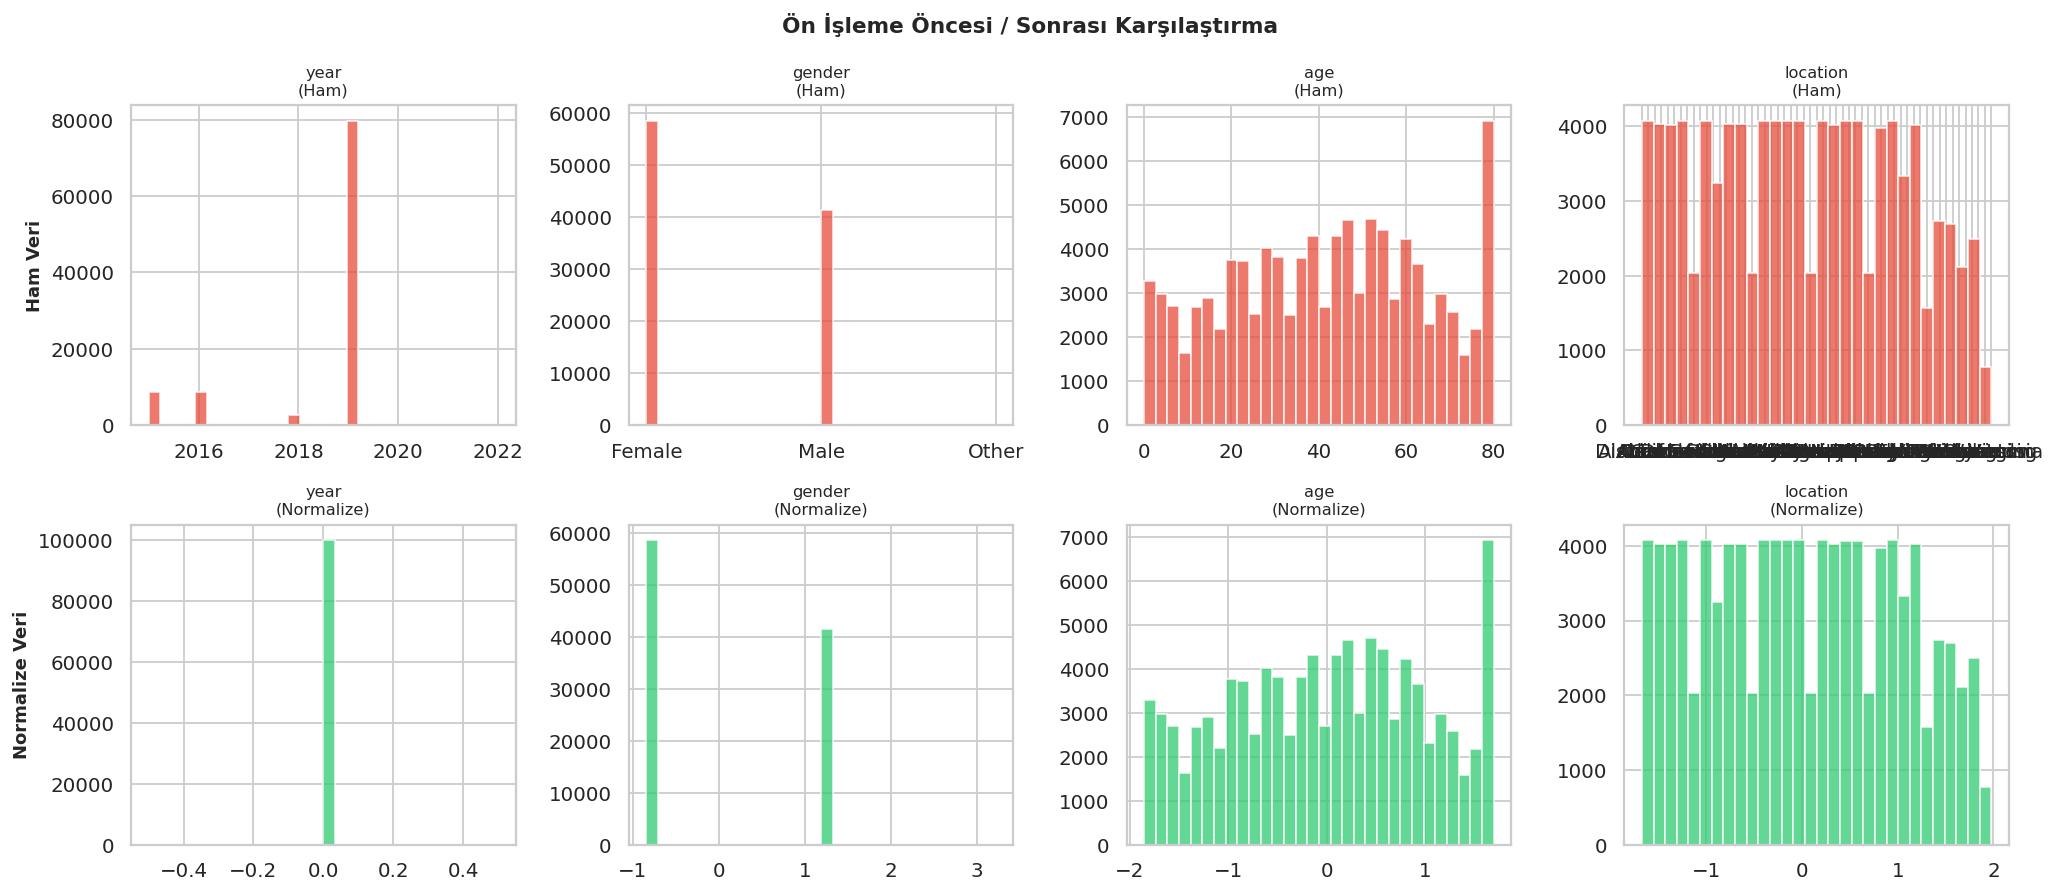

In [28]:
# ── 3.6 Ön işleme sonrası karşılaştırma görseli ──
sample_cols = feature_cols[:min(4, len(feature_cols))]

fig, axes = plt.subplots(2, len(sample_cols), figsize=(4*len(sample_cols), 7))
for i, col in enumerate(sample_cols):
    idx = feature_cols.index(col)
    raw_data = df_raw[col].dropna()
    proc_data = X[:, idx]

    axes[0, i].hist(raw_data, bins=30, color='#E74C3C', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Ham)', fontsize=9)

    axes[1, i].hist(proc_data, bins=30, color='#2ECC71', alpha=0.75, edgecolor='white')
    axes[1, i].set_title(f'{col}\n(Normalize)', fontsize=9)

axes[0, 0].set_ylabel('Ham Veri', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Normalize Veri', fontsize=10, fontweight='bold')

plt.suptitle('Ön İşleme Öncesi / Sonrası Karşılaştırma', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_preprocessing_comparison.png', bbox_inches='tight')
plt.show()

## 4 — İşlenmiş Veriyi Kaydet

In [29]:
# Offline RL yörüngeleri
def compute_reward(action):
    if action == 1:   return  1.0   # sabit tut → hedef aralık
    elif action == 0: return -1.0   # azalt → hipoglisemi riski
    elif action == 2: return -2.0   # artır → hiperglisemi
    return 0.0

states      = X[:-1]
actions     = y[:-1]
rewards     = np.array([compute_reward(a) for a in actions], dtype=np.float32)
next_states = X[1:]

print(f'Yörünge adımı: {len(states):,}')

# NumPy dosyası olarak kaydet
np.savez('processed_data.npz',
         X=X, y=y,
         states=states, actions=actions,
         rewards=rewards, next_states=next_states,
         feature_cols=np.array(feature_cols),
         num_actions=np.array([NUM_ACTIONS]),
         state_dim=np.array([X.shape[1]]))

# Scaler'ı kaydet (Notebook 2'de aynı dönüşüm için)
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('processed_data.npz kaydedildi.')
print('scaler.pkl kaydedildi.')
print('\n→ Bu dosyaları Notebook 2 için Google Drive\'a kopyalayın veya indirin.')

Yörünge adımı: 99,999
processed_data.npz kaydedildi.
scaler.pkl kaydedildi.

→ Bu dosyaları Notebook 2 için Google Drive'a kopyalayın veya indirin.


In [30]:
# Dosyaları indir
from google.colab import files
files.download('processed_data.npz')
files.download('scaler.pkl')

# EDA görsellerini zip'le ve indir
import zipfile
eda_imgs = [f for f in os.listdir('.') if f.startswith('eda_') and f.endswith('.png')]
with zipfile.ZipFile('EDA_gorseller.zip', 'w') as zf:
    for img in eda_imgs:
        zf.write(img)
        print(f'  + {img}')

files.download('EDA_gorseller.zip')
print('\n Tüm dosyalar indirildi. Notebook 2\'ye geçebilirsiniz.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  + eda_03_distributions.png
  + eda_05_outliers.png
  + eda_07_preprocessing_comparison.png
  + eda_06_violin_by_target.png
  + eda_04_correlation.png
  + eda_02_target_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Tüm dosyalar indirildi. Notebook 2'ye geçebilirsiniz.


---
## EDA Özet Tablosu

| Adım | Yapılan İşlem | Sonuç |
|------|--------------|-------|
| 1 | Ham veri yükleme | — satır, — sütun |
| 2 | Eksik değer analizi | Üst hücreye bakın |
| 3 | Hedef değişken inceleme | 3 sınıf: azalt/sabit/artır |
| 4 | Dağılım analizi | Histogram + çarpıklık |
| 5 | Korelasyon | Pearson r matrisi |
| 6 | Aykırı değer | IQR × 1.5 tespiti |
| 7 | Kategorik kodlama | LabelEncoder |
| 8 | Eksik değer doldurma | Medyan imputer |
| 9 | Aykırı değer kırpma | IQR clip |
| 10 | Normalizasyon | StandardScaler |

**Sonraki adım →** `ISE427_2_Model_Egitim.ipynb`